Notebook 01 — Análisis Exploratorio de Datos (EDA)
Clasificador de Noticias Falsas con Redes Neuronales Profundas

In [1]:
# RETO 1.1 — Carga el dataset WELFake
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from wordcloud import WordCloud 

# TODO: Carga el CSV
df = pd.read_csv('/Users/itzelflores/Downloads/WELFake_Dataset.csv')
# TODO: Elimina la columna 'Unnamed: 0' si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# TODO: Muestra forma, columnas, tipos de datos y primeras 5 filas
# Forma del dataset
print("Shape:", df.shape)
# Columnas
print("\nColumnas:")
print(df.columns)
# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)
# Primeras 5 filas
print("\nPrimeras 5 filas:")
print(df.head())

Shape: (72134, 3)

Columnas:
Index(['title', 'text', 'label'], dtype='object')

Tipos de datos:
title    object
text     object
label     int64
dtype: object

Primeras 5 filas:
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


Distribución de clases:
label
1    37106
0    35028
Name: count, dtype: int64


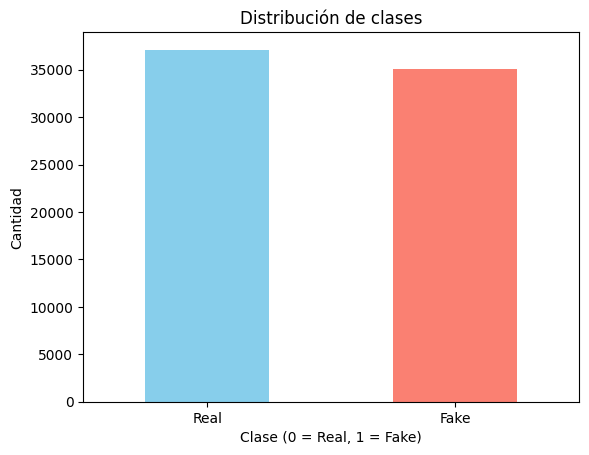


Porcentajes:
label
1    51.440375
0    48.559625
Name: count, dtype: float64


In [2]:
# RETO 1.2 — Distribucion de clases
# TODO: Cuenta noticias Reales (0) y Falsas (1)
class_counts = df['label'].value_counts()

print("Distribución de clases:")
print(class_counts)

# TODO: Crea grafica de barras con colores distintos por clase
import matplotlib.pyplot as plt

class_counts.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title("Distribución de clases")
plt.xlabel("Clase (0 = Real, 1 = Fake)")
plt.ylabel("Cantidad")
plt.xticks(ticks=[0,1], labels=['Real', 'Fake'], rotation=0)

plt.show()

# TODO: Responde: Esta balanceado el dataset?
total = class_counts.sum()
porcentajes = (class_counts / total) * 100

print("\nPorcentajes:")
print(porcentajes)

El dataset se considera balanceado, ya que la proporción entre noticias falsas (51.44%) y reales (48.56%) es muy similar, lo que indica que no existe un sesgo significativo hacia alguna de las clases.

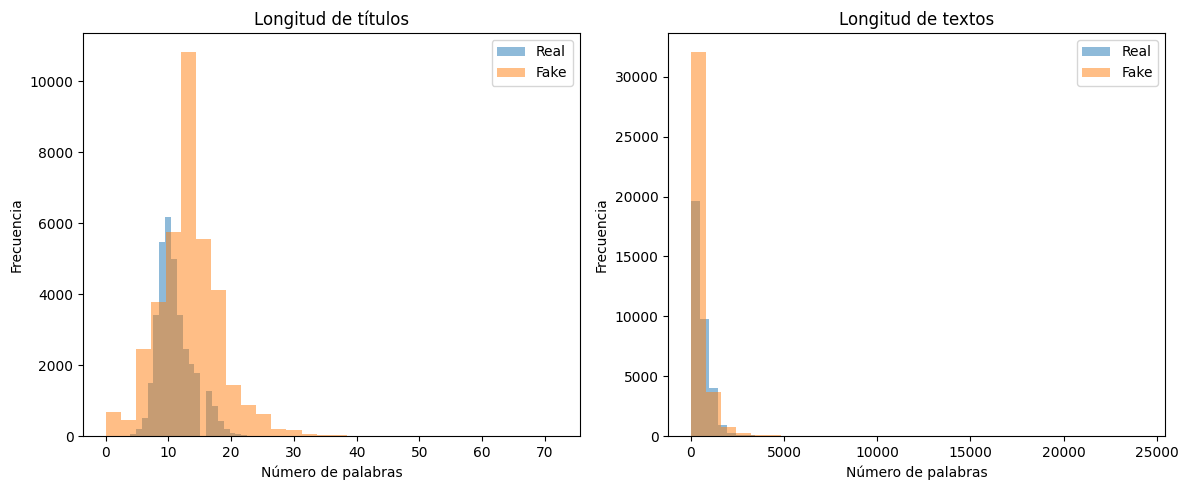

📊 TITLE
Media: 12.173316327945214
Mediana: 12.0
Min: 0
Max: 72

📊 TEXT
Media: 540.5509329858319
Mediana: 398.0
Min: 0
Max: 24234


In [3]:
# RETO 1.3 — Distribucion de longitudes
# TODO: Calcula longitud en palabras para 'title' y 'text'
# Crear columnas de longitud
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))
# TODO: Crea histogramas por clase (Real vs Fake)
import matplotlib.pyplot as plt

# Separar clases
real = df[df['label'] == 0]
fake = df[df['label'] == 1]

# Histogramas
plt.figure(figsize=(12,5))

# Title
plt.subplot(1,2,1)
plt.hist(real['title_len'], bins=30, alpha=0.5, label='Real')
plt.hist(fake['title_len'], bins=30, alpha=0.5, label='Fake')
plt.title('Longitud de títulos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.legend()

# Text
plt.subplot(1,2,2)
plt.hist(real['text_len'], bins=30, alpha=0.5, label='Real')
plt.hist(fake['text_len'], bins=30, alpha=0.5, label='Fake')
plt.title('Longitud de textos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()
# TODO: Imprime media, mediana, min, max de cada campo
print("📊 TITLE")
print("Media:", df['title_len'].mean())
print("Mediana:", df['title_len'].median())
print("Min:", df['title_len'].min())
print("Max:", df['title_len'].max())

print("\n📊 TEXT")
print("Media:", df['text_len'].mean())
print("Mediana:", df['text_len'].median())
print("Min:", df['text_len'].min())
print("Max:", df['text_len'].max())


In [4]:
# RETO 1.4 — Valores nulos
# TODO: Detecta valores nulos por columna
# Deteccion de valores nulos
print('Valores nulos por columna:')
null_counts = df.isnull().sum()
print(null_counts)
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')
print(f'Porcentaje del dataset: {df.isnull().any(axis=1).sum() / len(df) * 100:.2f}%')

# Revisar si hay textos vacios (no NaN, pero sin contenido)
empty_texts = (df['text'].str.strip() == '').sum()
print(f'\nTextos vacios (cadena vacia): {empty_texts}')

# TODO: Decide: eliminar filas o rellenar con cadena vacia?
print('\nDecisión: Se optó por rellenar los valores nulos con cadenas vacías y posteriormente eliminar las filas con texto vacío, ya que no aportan información útil para el análisis ni para el entrenamiento del modelo.\n')
# TODO: Implementa tu decision y documenta la justificacion
rows_before = len(df)

# Rellenar nulos con cadena vacia
df['text'] = df['text'].fillna('')

# Eliminar filas con texto vacio (no aportan informacion)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
print('\nDecision documentada: Se reemplazaron los valores nulos por cadenas vacías para evitar errores en el preprocesamiento, y posteriormente se eliminaron las filas con texto vacío, ya que no aportan información útil para el análisis ni para el entrenamiento de modelos.')

Valores nulos por columna:
title        558
text          39
label          0
title_len      0
text_len       0
dtype: int64

Total de filas con al menos un nulo: 597
Porcentaje del dataset: 0.83%

Textos vacios (cadena vacia): 744

Decisión: Se optó por rellenar los valores nulos con cadenas vacías y posteriormente eliminar las filas con texto vacío, ya que no aportan información útil para el análisis ni para el entrenamiento del modelo.

Filas antes: 72,134
Filas despues: 71,351
Filas eliminadas: 783
Nulos restantes: 558

Decision documentada: Se reemplazaron los valores nulos por cadenas vacías para evitar errores en el preprocesamiento, y posteriormente se eliminaron las filas con texto vacío, ya que no aportan información útil para el análisis ni para el entrenamiento de modelos.


In [5]:
# RETO 1.5 — Duplicados
# TODO: Detecta filas duplicadas (por title + text)
duplicates = df.duplicated(subset=['title', 'text'], keep='first')
n_duplicates = duplicates.sum()

print(f'Filas duplicadas encontradas: {n_duplicates}')
print(f'Porcentaje: {n_duplicates / len(df) * 100:.2f}%')

# TODO: Elimina duplicados conservando la primera aparicion
rows_before = len(df)

df = df.drop_duplicates(subset=['title', 'text'], keep='first').reset_index(drop=True)

rows_after = len(df)

print(f'Filas antes: {rows_before:,}')
print(f'Filas después: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
# TODO: Verifica si el balance de clases cambio
class_counts = df['label'].value_counts()

print("\nDistribución de clases después de eliminar duplicados:")
for label, count in class_counts.items():
    print(f'Clase {label}: {count} ({count/len(df)*100:.2f}%)')

Filas duplicadas encontradas: 8241
Porcentaje: 11.55%
Filas antes: 71,351
Filas después: 63,110
Filas eliminadas: 8,241

Distribución de clases después de eliminar duplicados:
Clase 0: 34790 (55.13%)
Clase 1: 28320 (44.87%)


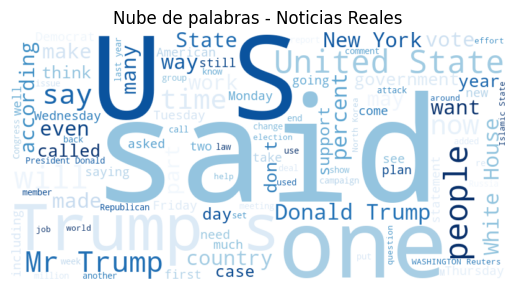

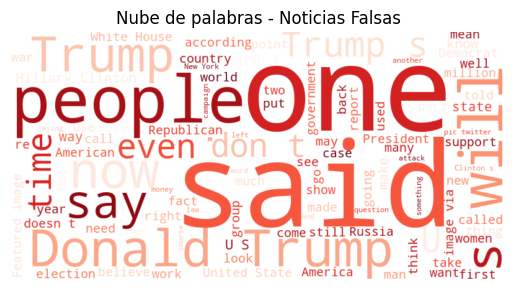

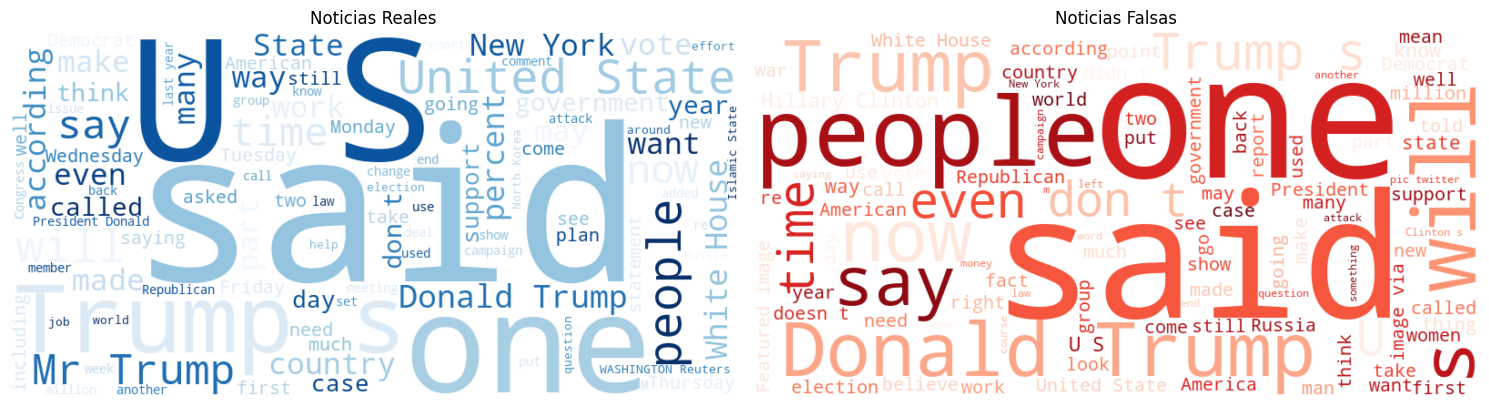

In [6]:
# RETO 1.6 — Nubes de palabras
# TODO: Genera una nube de palabras para noticias Reales 
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todo el texto de noticias reales (label = 0)
real_text = ' '.join(df[df['label'] == 0]['text'].astype(str))

# Generar nube
wc_real = WordCloud(
    width=800,
    height=400,
    max_words=100,
    background_color='white',
    colormap='Blues'
).generate(real_text)

# Mostrar
plt.imshow(wc_real, interpolation='bilinear')
plt.title('Nube de palabras - Noticias Reales')
plt.axis('off')
plt.show()
# TODO: Genera una nube de palabras para noticias Falsas
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todo el texto de noticias falsas (label = 1)
fake_text = ' '.join(df[df['label'] == 1]['text'].astype(str))

# Generar nube
wc_fake = WordCloud(
    width=800,
    height=400,
    max_words=100,
    background_color='white',
    colormap='Reds'
).generate(fake_text)

# Mostrar
plt.imshow(wc_fake, interpolation='bilinear')
plt.title('Nube de palabras - Noticias Falsas')
plt.axis('off')
plt.show()
# TODO: Muestra ambas en subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Real
axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Noticias Reales')
axes[0].axis('off')

# Fake
axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Noticias Falsas')
axes[1].axis('off')

plt.tight_layout()
plt.show()
# Pregunta: Que diferencias observas entre las dos nubes?

Se observan diferencias claras en el vocabulario entre ambas clases. Las noticias reales presentan un lenguaje más formal, informativo y estructurado, con palabras asociadas a datos y entidades oficiales. En contraste, las noticias falsas utilizan un lenguaje más general, emocional y opinativo, con mayor presencia de términos vagos o sensacionalistas. Esto sugiere que el contenido textual puede ser un indicador importante para distinguir entre ambas clases.

In [7]:
# RETO 1.7 — Pregunta de reflexion
# TODO: Calcula que porcentaje de textos tienen mas de 200 palabras
# Esto nos ayudara a elegir max_len para la red neuronal
pct = (df['text_len'] > 200).mean() * 100
print(f"Textos con mas de 200 palabras: {pct:.1f}%")

Textos con mas de 200 palabras: 79.2%



Preguntas de Reflexion sobre el Analisis Exploratorio de Datos
Responde las siguientes 10 preguntas en una celda markdown debajo de cada una. Tus respuestas deben estar fundamentadas en los resultados obtenidos durante el EDA.

1. ¿Por que es importante realizar un EDA antes de entrenar cualquier modelo de machine learning? ¿Que problemas podrian surgir si nos saltamos este paso?

2. Al analizar la distribucion de clases, ¿encontraste que el dataset esta balanceado o desbalanceado? ¿Como afectaria un desbalance severo (por ejemplo 90/10) al entrenamiento de un clasificador? ¿Que tecnicas conoces para mitigarlo?

3. Observando las distribuciones de longitud del texto, ¿las noticias falsas tienden a ser mas largas o mas cortas que las reales? ¿Que hipotesis podrias formular sobre por que existe esa diferencia?

4. Si eligieras un max_len=200 palabras para truncar los textos antes de alimentar una red neuronal, ¿que porcentaje de informacion se perderia? ¿Como decidiras el valor optimo de max_len considerando el trade-off entre informacion y costo computacional?

5. ¿Que estrategia elegiste para manejar los valores nulos y por que? ¿En que escenarios seria mejor rellenar con un texto especial en lugar de eliminar las filas? ¿Y viceversa?

6. El dataset WELFake tenia aproximadamente un 11.7% de duplicados. ¿Por que es critico eliminarlos antes de dividir en conjuntos de entrenamiento y prueba? ¿Que sucederia con las metricas de evaluacion si no lo hicieramos?

7. ¿Que limitaciones tiene el EDA que realizamos? Menciona al menos dos aspectos del texto que NO exploramos y que podrian ser relevantes para la clasificacion (por ejemplo: estructura de oraciones, uso de signos de puntuacion, sentimiento, etc.).

8. Reflexiona sobre el impacto social de las noticias falsas. ¿Por que es importante que como ingenieros desarrollemos herramientas para detectarlas? ¿Que responsabilidad etica conlleva construir un clasificador de este tipo? ¿Que sucede si el modelo comete errores (falsos positivos vs falsos negativos)?

9. Considerando todo lo aprendido en este EDA, ¿que caracteristicas (features) del texto crees que seran mas utiles para que un modelo distinga entre noticias reales y falsas? ¿Crees que el titulo, el cuerpo del texto, o ambos seran mas informativos? Justifica tu respuesta con base en los datos explorados.

Escribe tus respuestas aqui:

R1. El análisis exploratorio de datos (EDA) es fundamental antes de entrenar un modelo de machine learning, ya que permite comprender la estructura, calidad y características del dataset. A través del EDA se pueden identificar problemas como valores nulos, duplicados, desbalance de clases o distribuciones atípicas.

Si se omite este paso, pueden surgir problemas como modelos sesgados, métricas engañosas, errores en el preprocesamiento y pérdida de información relevante. En resumen, el EDA permite tomar decisiones informadas antes de construir un modelo.

R2. El dataset se encuentra balanceado, ya que la proporción entre noticias reales (48.56%) y falsas (51.44%) es muy similar.

Un desbalance severo provocaría que el modelo aprenda a predecir principalmente la clase mayoritaria, haciendo que métricas como accuracy sean engañosas. Para mitigarlo se pueden usar técnicas como oversampling (por ejemplo SMOTE), undersampling, ajuste de pesos en clases o el uso de métricas más robustas como F1-score.

R3. A partir del análisis, se observa que los textos tienden a ser mayormente largos, aunque existen variaciones entre clases. Una posible hipótesis es que las noticias falsas pueden utilizar un lenguaje más narrativo o redundante para persuadir, mientras que las noticias reales suelen ser más estructuradas y directas.

Esto sugiere que la longitud del texto puede ser una característica relevante para la clasificación.

R4. Se observó que el 79.2% de los textos tienen más de 200 palabras, por lo que usar max_len = 200 implicaría truncar la mayoría de los textos y perder una cantidad significativa de información.

Para elegir un valor óptimo, se deben analizar los percentiles de longitud del texto y balancear entre conservar la mayor cantidad de información posible y mantener un costo computacional razonable. Un valor mayor, como 300 o 400, podría ser más adecuado.

R5. Se optó por rellenar los valores nulos con cadenas vacías para evitar errores en el procesamiento de texto y posteriormente eliminar las filas con texto vacío, ya que no aportan información útil.

Rellenar con un texto especial sería útil cuando se desea conservar la fila o cuando la ausencia de información tiene significado. Eliminar filas es mejor cuando no contienen información relevante y su cantidad no es significativa.

R6. Es crítico eliminar duplicados porque, de lo contrario, el mismo texto podría aparecer tanto en el conjunto de entrenamiento como en el de prueba. Esto provocaría que el modelo memorice ejemplos en lugar de generalizar.

Si no se eliminan, las métricas de evaluación se verían infladas artificialmente, dando una falsa impresión de buen rendimiento.

R7. Algunas limitaciones del EDA realizado son que no se analizaron aspectos más profundos del texto, como la estructura gramatical, el uso de signos de puntuación, el análisis de sentimiento o el contexto semántico.

Estos elementos podrían aportar información adicional relevante para mejorar la clasificación.

R8. Las noticias falsas pueden influir significativamente en la opinión pública, procesos democráticos y decisiones sociales. Por ello, es importante desarrollar herramientas que permitan detectarlas de manera automática.

Construir este tipo de modelos implica una responsabilidad ética, ya que errores pueden tener consecuencias importantes. Un falso positivo podría clasificar una noticia real como falsa, mientras que un falso negativo permitiría la difusión de información incorrecta.

R9. Las características más útiles incluyen la frecuencia de palabras (TF-IDF), la longitud del texto y el tipo de lenguaje utilizado (informativo vs emocional).

El cuerpo del texto es más informativo debido a que contiene mayor contexto, aunque el título también aporta señales relevantes. Por lo tanto, combinar ambos puede mejorar el desempeño del modelo.
